Downloading/Loading Faster R-CNN model... (This may take a minute)
Model loaded successfully!
Scanning image for objects...


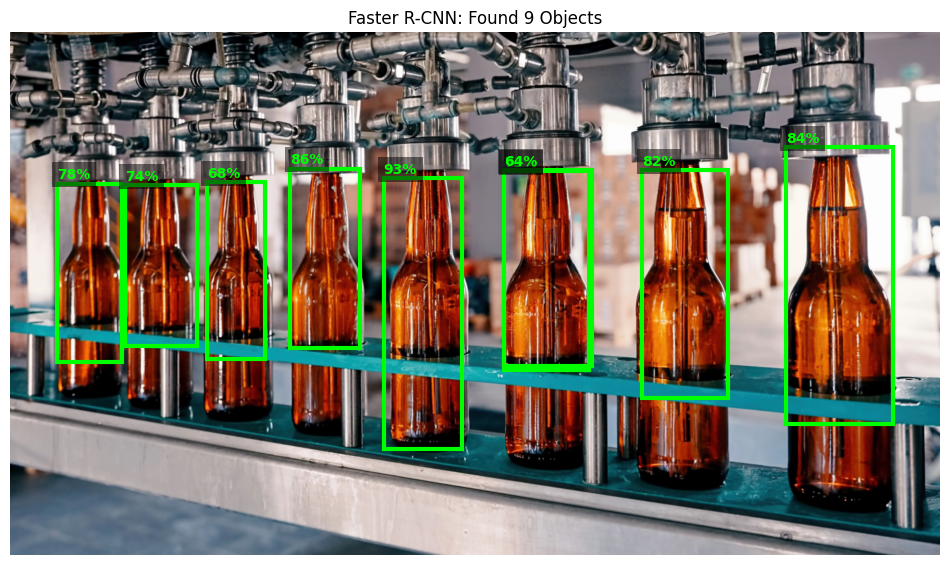


✅ SUCCESS! Detected 9 objects.
ᄃ Saved visualization to: 1.png


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("Downloading/Loading Faster R-CNN model... (This may take a minute)")

# 1. MODEL SETUP
MODEL_URL = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
detector = hub.load(MODEL_URL)
print("Model loaded successfully!")

# 2. IMAGE PREPROCESSING
# Updated to match the existing file: /content/1.jpeg
# Please upload your image file to the Colab environment (e.g., to /content/) or provide a publicly accessible URL.
# For example, after uploading 'defect-detection-TAO-bottles.png' to /content/, the path would be:
file_path = "/content/1.jpeg"

if not os.path.exists(file_path):
    print(f"\u274c ERROR: '{file_path}' not found!")
    raise SystemExit("Image file missing.")

# Read and convert to RGB
img = cv2.imread(file_path)
if img is None:
    raise SystemExit("Error: OpenCV could not read the image.")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Model expects tensor batch: [1, Height, Width, 3]
img_tensor = tf.convert_to_tensor(img_rgb, dtype=tf.uint8)
img_tensor = tf.expand_dims(img_tensor, 0)

# 3. INFERENCE
print("Scanning image for objects...")
results = detector(img_tensor)

# Extract boxes and scores
boxes = results["detection_boxes"][0].numpy()
scores = results["detection_scores"][0].numpy()

# 4. VISUALIZATION
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
h, w, _ = img_rgb.shape

min_confidence = 0.50
detections = 0

for i in range(len(scores)):
    if scores[i] >= min_confidence:
        detections += 1
        ymin, xmin, ymax, xmax = boxes[i]

        y1, x1 = int(ymin * h), int(xmin * w)
        y2, x2 = int(ymax * h), int(xmax * w)

        plt.gca().add_patch(
            plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='#00ff00', linewidth=3)
        )

        score_text = f"{scores[i]*100:.0f}%"
        plt.text(
            x1, y1 - 10, score_text, color='#00ff00', fontsize=10, weight='bold',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')
        )

plt.title(f"Faster R-CNN: Found {detections} Objects")
plt.axis('off')

output_filename = "1.png"
plt.savefig(output_filename, bbox_inches='tight')
plt.show()

print(f"\n✅ SUCCESS! Detected {detections} objects.")
print(f"ᄃ Saved visualization to: {output_filename}")